In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

os.makedirs('data/models/weights', exist_ok=True)
os.makedirs('data/models/histories', exist_ok=True)

In [2]:
import tensorflow as tf
import numpy as np
import random
import json

from src.networks.DecoderPINN import PINN
from src.optimization.DecoderTrainer import DecoderTrainer
from src.data.dataloader import load_parametric_fem_data_lbfgs
from src.data.collocation import generate_parametric_collocation_points
from src.visualization.historyplots import plot_lbfgs_history
from src.visualization.pdeplots import get_eval_grid, plot_parametric_pinn_solution
from src.physics.physics import get_M_dynamic
from src.hyperparameters import hypers_uqvae as h

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

2026-09-10 17:43:52.100275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789055032.110317  466963 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789055032.113177  466963 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789055032.120747  466963 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789055032.120760  466963 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789055032.120762  466963 computation_placer.cc:177] computation placer alr

In [3]:
train_path = 'data/fem/fem_parametric_train.npz'
val_path = 'data/fem/fem_parametric_val.npz'
test_path = 'data/fem/fem_parametric_test.npz'
scale_load_path = 'data/models/u_scale_var.npy'

# Load parametric FEM data
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_parametric_fem_data_lbfgs(
    train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    scale_load_path=scale_load_path,
    n_lbfgs_data=25000,
    noise_level=h.NOISE,
    dtype=number_type
)

Loading Parametric FEM data for L-BFGS from:
data/fem/fem_parametric_train.npz
data/fem/fem_parametric_val.npz
data/fem/fem_parametric_test.npz
U_SCALE (loaded): 0.07060286428244116


I0000 00:00:1789055034.224484  466963 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


Injected Gaussian noise with stddev: 0.02
Shape x_train: (25000, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)


In [4]:
# Model creation
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 4), dtype=number_type))  # 4 input [x, y, cx, cy]

# Transfer Learning
with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']

pretrained_weights = f'data/models/weights/{pipeline_id}_decoder_adam.weights.h5'
model.load_weights(pretrained_weights)
print(f"Transfer Learning inizializzato dai pesi Adam: {pretrained_weights}")

Transfer Learning inizializzato dai pesi Adam: data/models/weights/20260910_162018_decoder_adam.weights.h5


In [5]:
N_interior = h.N_INTERIOR_LBFGS
N_boundary = h.N_BOUNDARY_LBFGS  # Punti per lato del quadrato
N_activation = h.N_ACTIVATION_LBFGS

x_int, x_boundary, n_boundary, num_neumann = generate_parametric_collocation_points(N_interior, N_boundary, N_activation, dtype=number_type)

In [6]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_LBFGS,
    'neu': h.LAMBDA_NEU_LBFGS,
    'dir': h.LAMBDA_DIR_LBFGS,
    'data': h.LAMBDA_DATA_LBFGS
}

trainer = DecoderTrainer(model=model, pipeline_id=pipeline_id)

trainer.train_lbfgs(x_int=x_int,
                    x_boundary=x_boundary,
                    n_boundary=n_boundary,
                    num_neumann=num_neumann,
                    x_data=x_train_pinn,
                    u_data=u_train_pinn,
                    x_val=x_val_pinn,
                    u_val=u_val_pinn,
                    physics_fn=get_M_dynamic,
                    lambdas=lambdas,
                    max_iterations=h.MAX_LBFGS_ITERATIONS,
                    num_correction_pairs=h.NUM_CORRECTION_PAIRS_LBFGS,
                    tolerance=h.TOLERANCE_LBFGS,
                    x_tolerance=h.X_TOLERANCE_LBFGS,
                    f_relative_tolerance=h.F_RELATIVE_TOLERANCE_LBFGS,
                    number_type=number_type)


Starting L-BFGS optimization...


I0000 00:00:1789055035.662127  466963 service.cc:152] XLA service 0x55a4c47b4120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789055035.662167  466963 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1789055036.025413  466963 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1789055037.828272  466963 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Call to loss_grad: 0 | Loss: 0.0045668200107939743 | PDE: 1.9095308415813145e-05 | Dir: 1.0729527086420244e-06 | Neu: 7.7499490101320744e-05 | Data: 0.00042677966608706275 | Validation: 3.4319259724334868e-05
Call to loss_grad: 500 | Loss: 0.0042739310356453364 | PDE: 1.4075033081233687e-05 | Dir: 1.1628896098137424e-07 | Neu: 0.00011361764272364109 | Data: 0.00041204156323076257 | Validation: 2.3889442740174547e-05
Call to loss_grad: 1000 | Loss: 0.0042026436681525565 | PDE: 1.2418865481060617e-05 | Dir: 1.0278576441468542e-07 | Neu: 0.0001285273638096086 | Data: 0.00040668911632623858 | Validation: 1.898711824161735e-05
Call to loss_grad: 1500 | Loss: 0.0041577326921453991 | PDE: 1.1281530113349577e-05 | Dir: 8.8673185578973078e-08 | Neu: 0.00014031448179054892 | Data: 0.00040346469276361 | Validation: 1.6302951253671882e-05
Call to loss_grad: 2000 | Loss: 0.0041296342806576083 | PDE: 1.0397532346137514e-05 | Dir: 8.5391131922857933e-08 | Neu: 0.00017040597271453874 | Data: 0.0004015

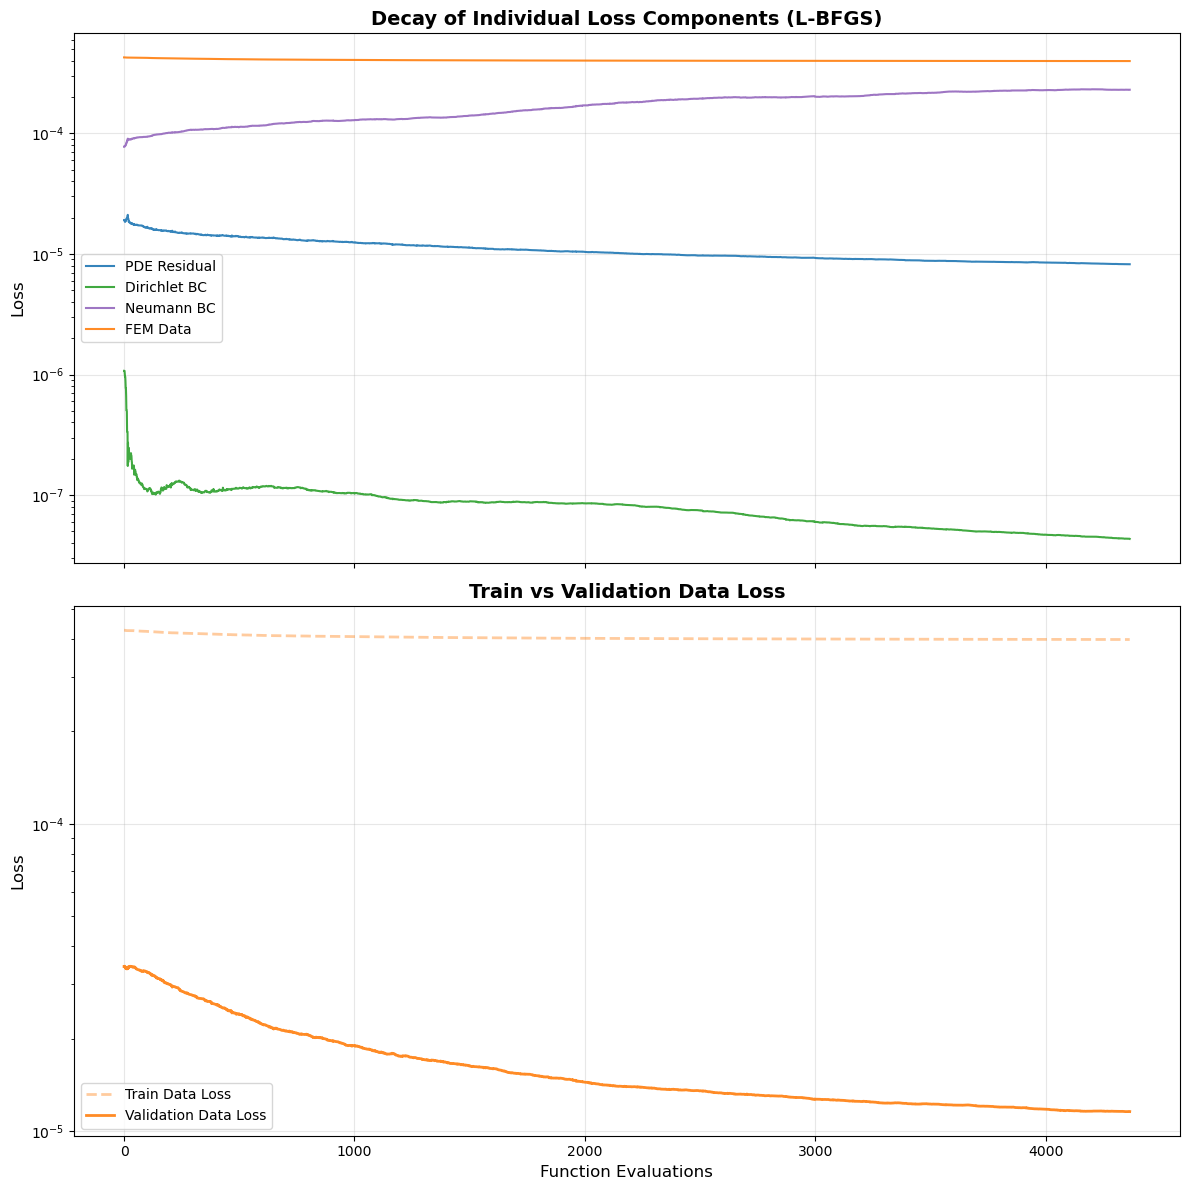

In [7]:
plot_lbfgs_history(trainer.history_lbfgs)

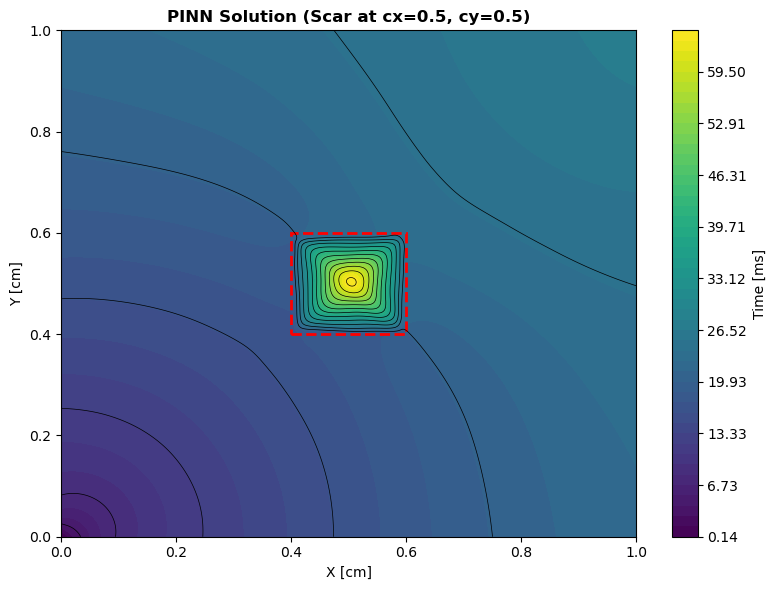

In [8]:
cx_test, cy_test = 0.5, 0.5
X, Y, X_tensor = get_eval_grid(N=400, cx=cx_test, cy=cy_test, dtype=number_type)

u_pred_flat = model(X_tensor).numpy() * U_SCALE
U_PINN = u_pred_flat.reshape(400, 400) * 1000.0

plot_parametric_pinn_solution(X, Y, U_PINN, cx_test, cy_test, lato_cicatrice=0.2)

In [9]:
from src.utils.metrics import compute_test_metrics
# ground truth FEM solution for the same scar center
data_test = np.load('data/fem/fem_parametric_test.npz')
coords_test = data_test['coords']   
values_test = data_test['values']   

# 2. Compute test metrics
l2_error, mae_error = compute_test_metrics(
    model=model, 
    coords_test=coords_test, 
    values_test=values_test, 
    U_SCALE=U_SCALE, 
    dtype=number_type
)

l2 Relative Error vs FEM Ground Truth: 1.1326%
Mean Absolute Error (Physical): 0.1248 ms
